In [1]:
import qutip as qt
import numpy as np
import xarray as xr
import os
import matplotlib.pyplot as plt
import scipy.linalg as la
from cmath import sqrt

fit exponents: [-1.63061326-6.07324151e-17j -0.52297519+5.74282453e-17j]
fit Residues: [-0.56963535+2.41540451e-16j  1.55776519-2.09844522e-16j]
fit error: 0.09277544388793772


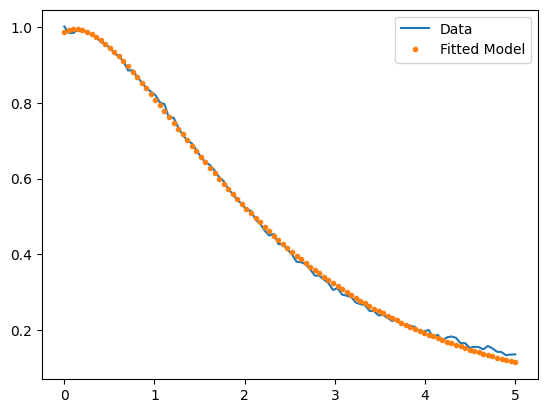

In [262]:
"""
Matrix Pencil Method for exponential signal decomposition.

This script extracts exponential poles and residues from experimental
time-domain data using the matrix pencil method (MPM).

Steps:
1. Construct Hankel matrix from time-series data
2. Perform SVD to separate signal and noise subspaces
3. Solve the matrix pencil eigenvalue problem to obtain poles
4. Convert poles to continuous-time exponents
5. Estimate residues via least-squares fitting
"""
Gamma = 0.6
def G(t, Gamma, Lambda=1):
    d = sqrt(Lambda*(Lambda - 2*Gamma))
    return np.exp(-Lambda*t/2)* ( np.cosh(d*t/2) + Lambda/d*np.sinh(d*t/2) )

tlist = np.linspace(0,5,100)
y_data = G(tlist,Gamma) **2
y_data = y_data*0.9 +0.1 + np.random.normal(0, 0.005, size=len(y_data))


# Matrix Pencil Method for extracting exponents
N = len(y_data)
L = N//2
dt = tlist[1] - tlist[0]
Y = np.array([ [y_data[i+j] for j in range(L+1)] for i in range(N-L)])
U,s,Vh = la.svd(Y, full_matrices = False)

threshold = 1e-2
s_filtered = s[s/s[0] > threshold]
M = len(s_filtered)
#M = 1
V = Vh.conj().T
V_filtered = V[:, :M]
V1 = V_filtered[:-1, :]
V2 = V_filtered[1: , :]
V1h = V1.conj().T
V2h = V2.conj().T

Z = la.pinv(V1h) @ V2h
eigvals = la.eigvals(Z)
eigvals = eigvals[np.abs(eigvals) > 1e-4]
exponents = np.log(eigvals) / dt
print("fit exponents:",exponents)

# Finding Residues
Z = np.zeros((N, M), dtype=complex)
for i in range(M):
    Z[:, i] = np.exp(exponents[i] * tlist)
R, _, _, _ = la.lstsq(Z, y_data)
print("fit Residues:", R)

# the fitted model
y_fit = Z @ R
error = np.linalg.norm(y_data - y_fit)
print("fit error:", error)

# Plotting the results
#plt.yscale("log")
plt.plot( tlist, np.real(y_data), label='Data')
plt.plot( tlist, np.real(y_fit),"." ,label='Fitted Model')
plt.legend()

# eigenvalues verses $\Gamma$

In [305]:
poles = []
s_filtered_list = []
R_list = []
s_list = []
Gamma_list = np.linspace(0,1, 40)
for Gamma in Gamma_list:
    y_data = np.array([ G(t, Gamma)**2 for t in tlist])
    y_data = y_data*1 +0.06 +np.random.normal(0, 0.005, size=len(y_data))

    
    # Matrix Pencil Method for extracting exponents
    N = len(y_data)
    L = N//2
    dt = tlist[1] - tlist[0]
    Y = np.array([ [y_data[i+j] for j in range(L+1)] for i in range(N-L)])
    U,s,Vh = la.svd(Y, full_matrices = False)
    s_list.append(s)
    
    threshold = 2e-3
    s_filtered = s[s/s[0] > threshold]
    # threshold = 1e-1
    # s_filtered = s[s > threshold]

    s_filtered_list.append(s_filtered)
    M = len(s_filtered)
    #M = 3
    V = Vh.conj().T
    V_filtered = V[:, :M]
    V1 = V_filtered[:-1, :]
    V2 = V_filtered[1: , :]
    V1h = V1.conj().T
    V2h = V2.conj().T
    
    Z = la.pinv(V1h) @ V2h
    eigvals = la.eigvals(Z)
    eigvals = eigvals[np.abs(eigvals) > 1e-3]
    exponents = np.log(eigvals) / dt
    poles.append(exponents)

    # Finding Residues
    Z = np.zeros((N, M), dtype=complex)
    for i in range(M):
        Z[:, i] = np.exp(exponents[i] * tlist)
    R, _, _, _ = la.lstsq(Z, y_data)
    R_list.append(R)

(-1.0, 1.0)

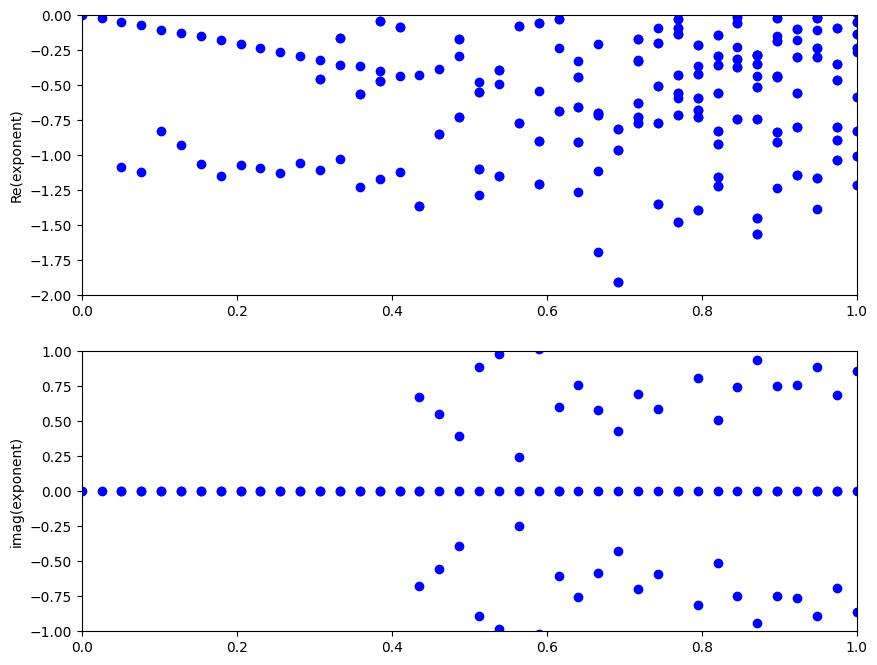

In [306]:
plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
for i, exps in enumerate(poles):
    for e in exps:
        plt.scatter(Gamma_list[i], np.real(e), color='blue')
plt.ylabel("Re(exponent)")
plt.xlim(0, 1)
plt.ylim(-2, 0)

plt.subplot(2,1,2)
for i, exps in enumerate(poles):
    for e in exps:
        plt.scatter(Gamma_list[i], np.imag(e), color='blue')
plt.ylabel("imag(exponent)")
plt.xlim(0, 1)
plt.ylim(-1, 1)

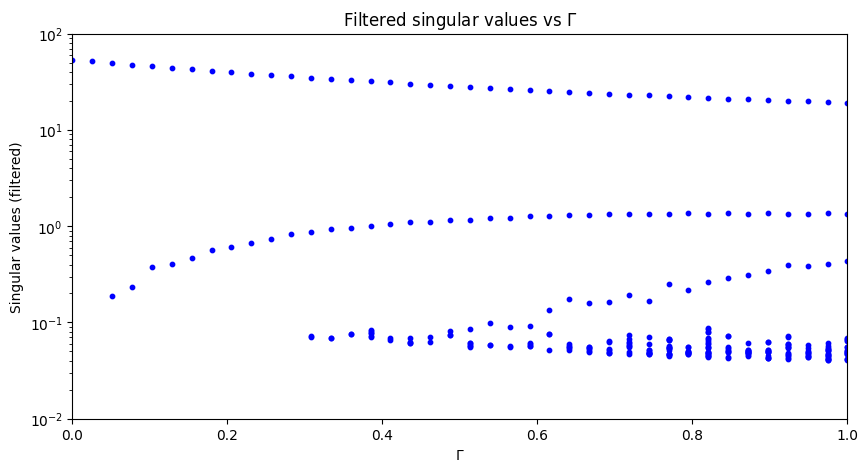

In [307]:
plt.figure(figsize=(10, 5))
for i, (gamma, s_vals) in enumerate(zip(Gamma_list, s_filtered_list)):
    for s_val in s_vals:
        plt.scatter(gamma, s_val, color='blue', s=10)
plt.xlabel(r"$\Gamma$")
plt.ylabel("Singular values (filtered)")
plt.title(r"Filtered singular values vs $\Gamma$")
plt.yscale("log")
plt.xlim(0, 1)
plt.ylim(1e-2, 100)
plt.show()

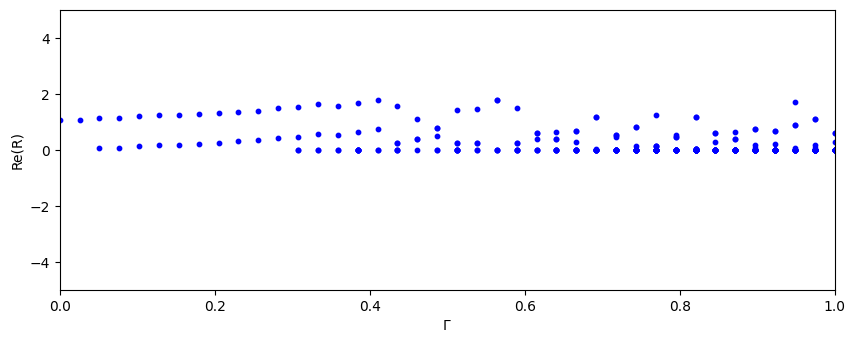

In [308]:
plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
for i, r_vals in enumerate(R_list):
    for r in r_vals:
        plt.scatter(Gamma_list[i], np.abs(r), color='blue', s=10)
plt.xlabel(r"$\Gamma$")
plt.ylabel("Re(R)")
plt.xlim(0, 1)
plt.ylim(-5, 5)

plt.show()

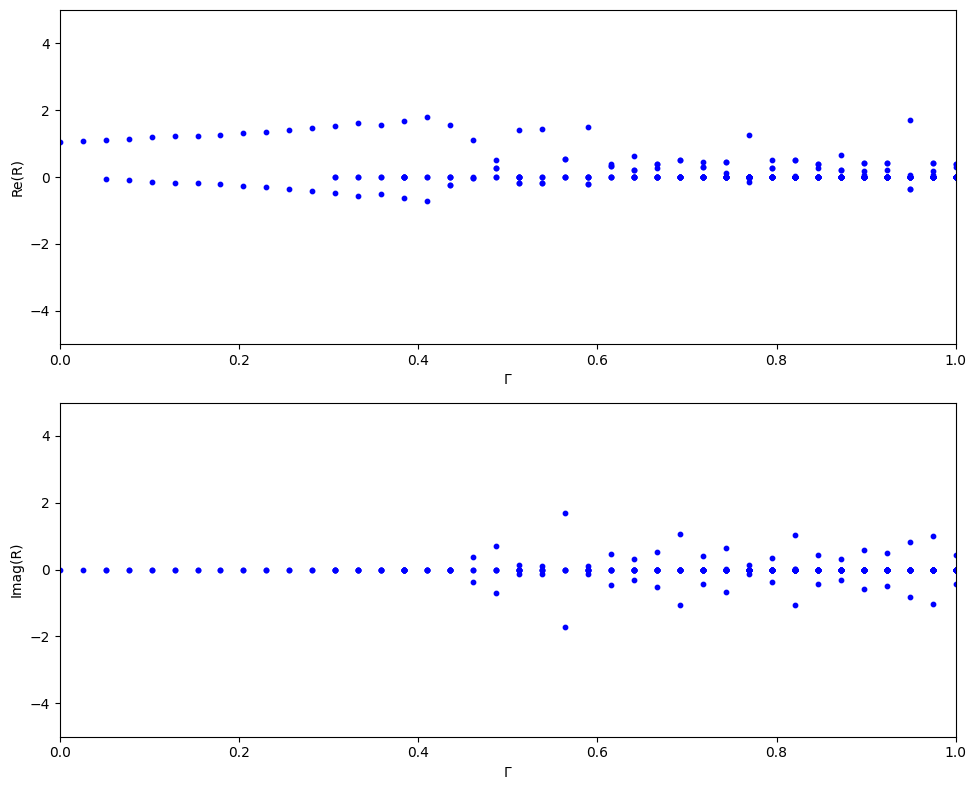

In [309]:
plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
for i, r_vals in enumerate(R_list):
    for r in r_vals:
        plt.scatter(Gamma_list[i], np.real(r), color='blue', s=10)
plt.xlabel(r"$\Gamma$")
plt.ylabel("Re(R)")
plt.xlim(0, 1)
plt.ylim(-5, 5)

plt.subplot(2,1,2)
for i, r_vals in enumerate(R_list):
    for r in r_vals:
        plt.scatter(Gamma_list[i], np.imag(r), color='blue', s=10)
plt.xlabel(r"$\Gamma$")
plt.ylabel("Imag(R)")
plt.tight_layout()
plt.xlim(0, 1)
plt.ylim(-5, 5)

plt.show()

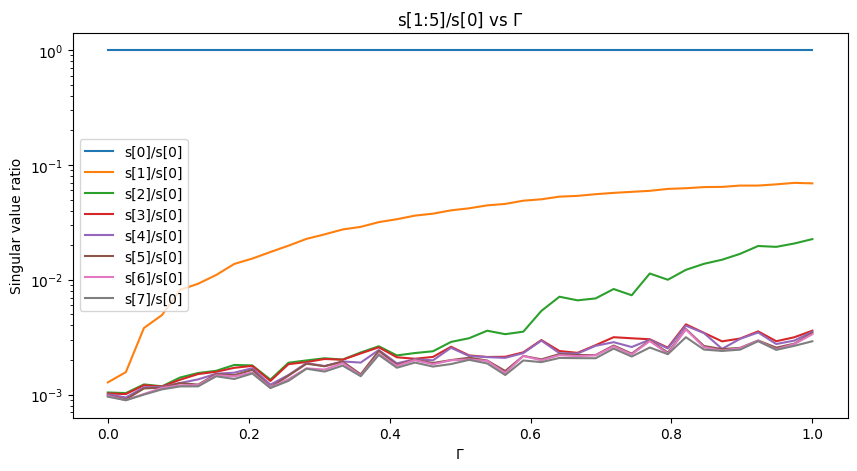

In [310]:
s_array = np.array(s_list)
plt.figure(figsize=(10, 5))
for idx in range(0, 8):
    plt.plot(Gamma_list, s_array[:, idx] / s_array[:, 0], label=f"s[{idx}]/s[0]")
plt.xlabel(r"$\Gamma$")
plt.ylabel("Singular value ratio")
plt.title(r"s[1:5]/s[0] vs $\Gamma$")
plt.legend()
plt.yscale("log")
plt.show()

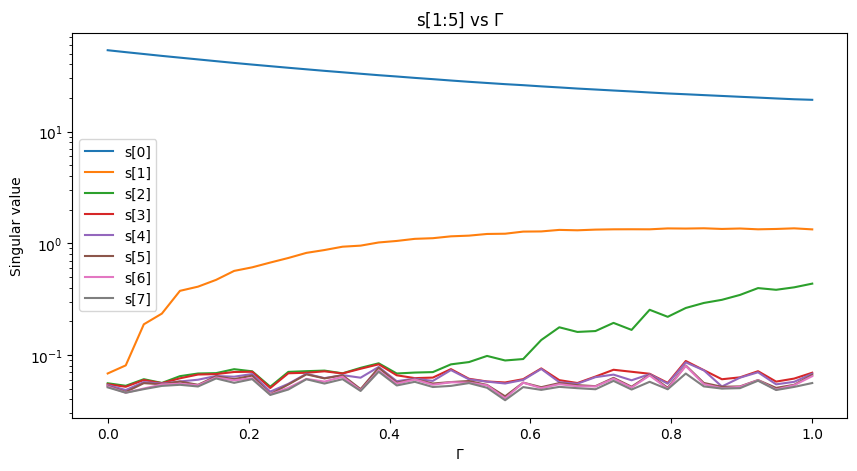

In [311]:
s_array = np.array(s_list)
plt.figure(figsize=(10, 5))
for idx in range(0, 8):
    plt.plot(Gamma_list, s_array[:, idx], label=f"s[{idx}]")
plt.xlabel(r"$\Gamma$")
plt.ylabel("Singular value")
plt.title(r"s[1:5] vs $\Gamma$")
plt.legend()
plt.yscale("log")
plt.show()